<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp1_1sreda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Часть 1. Генерация данных**

Установка библиотек + проверка устройства

In [1]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-jg8fs4iq
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-jg8fs4iq
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=2233b9c865f861c1ed1ef28cde7c0808ba800c9856396408d71040094bfac036
  Stored in directory: /tmp/pip-ephem-wheel-cache-ebrlczta/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


Генерация траекторий численным интегрированием: координата *x(t)*, скорость *v(t)* и ускорение *a(t)*

In [3]:
k, m, c = 4.0, 1.0, 0.3  # жёсткость, масса, сопротивление среды
noise_level = 0.01  # гауссов шум - % от стандартного отклонения a

def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for x0 in [1.0, 0.5, 2.0]: # цикл по начальным условиям
    for v0 in [0.0, 0.5, -0.5]:

        sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 500))
        # запуск численного интегрирования от t[0,20], 500 значений

        x, v = sol.y # извлечение из результата (sol) массив из координат и скоростей
        a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

        # с шумом
        a_std = np.std(a_clean) # амплитуда сигнала для этой траектории
        noise = np.random.normal(0, noise_level * a_std, size=len(a_clean))
        a_noisy = a_clean + noise

        for i in range(len(x)):
            all_data.append([x[i], v[i], a_noisy[i]])   # сохранение зашумлённого a

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")   # 9 траекторий × 500 = 4500

Всего точек: 4500


Формирование датасета из полученных данных (входы: *x*,*v*, выход: *a*)

In [4]:
X = all_data[:, :2]   # (x, v)
y = all_data[:, 2]    # a

# pазбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_raw = X_train.astype(np.float32)
X_test_raw  = X_test.astype(np.float32)
y_train_raw = y_train.astype(np.float32).reshape(-1, 1)
y_test_raw  = y_test.astype(np.float32).reshape(-1, 1)

# Тензоры
X_train_t = torch.tensor(X_train_raw, dtype=torch.float32)
y_train_t = torch.tensor(y_train_raw, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_raw, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_raw, dtype=torch.float32)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

train: 3600 примеров, test: 900 примеров


# **Часть 2. Создание и обучение KAN [2,2,1] (66 параметров)**

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.34e-02 | test_loss: 4.35e-02 | reg: 1.85e+01 | : 100%|█| 50/50 [00:15<00:00,  3.21it


saving model version 0.1


| train_loss: 4.08e-02 | test_loss: 4.09e-02 | reg: 1.91e+01 | : 100%|█| 50/50 [00:16<00:00,  2.95it


saving model version 0.2


...

saving model version 0.8


| train_loss: 1.57e-02 | test_loss: 1.61e-02 | reg: 1.85e+01 | : 100%|█| 50/50 [00:07<00:00,  6.95it


saving model version 0.9


| train_loss: 1.57e-02 | test_loss: 1.61e-02 | reg: 1.85e+01 | : 100%|█| 50/50 [00:05<00:00,  8.39it


saving model version 0.10
MSE KAN: 0.00025822


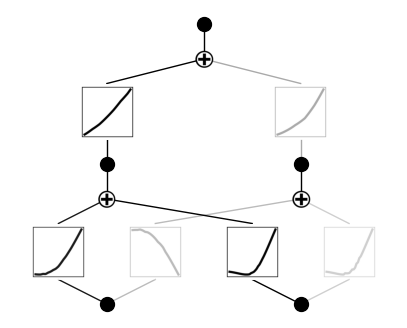

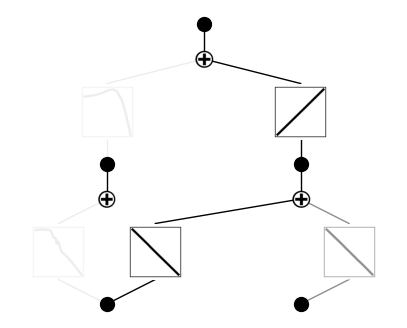

In [12]:
model_kan = KAN(width=[2, 2, 1], grid=10, k=1, seed=42, device=device)
# k=1 так как вычисляемая функция линейна, такого порядка сплайна достаточно

model_kan(dataset['train_input']) # инициализация, визуализация
model_kan.plot()

steps = 10
train_losses_kan = []
test_losses_kan = []
# обучаем по одному шагу, сохраняя потери
for step in range(steps):
    res = model_kan.fit(dataset, opt="LBFGS", steps=50, lamb=0.0) # 500 шагов обучения
    train_losses_kan.append(float(res['train_loss'][-1]))
    test_losses_kan.append(float(res['test_loss'][-1]))

model_kan.plot() # визуализация

# конечная ошибка на тесте
with torch.no_grad():
    pred_kan_scaled = model_kan(dataset['test_input'])
    mse_kan_scaled = nn.functional.mse_loss(pred_kan_scaled, dataset['test_label'])
print(f"MSE KAN: {mse_kan_scaled.item():.8f}")

Символьная регрессия

saving model version 0.11
fixing (0,0,0) with 0
fixing (0,0,1) with x, r2=0.9998518824577332, c=1
fixing (0,1,0) with 0
fixing (0,1,1) with x, r2=0.9998951554298401, c=1
fixing (1,0,0) with 0
fixing (1,1,0) with x, r2=0.9999834299087524, c=1
saving model version 0.12
Символьная формула KAN: -4.0737*x_1 - 0.3019*x_2 - 0.0004
Реальная символьная формула: -4.0 + -0.3


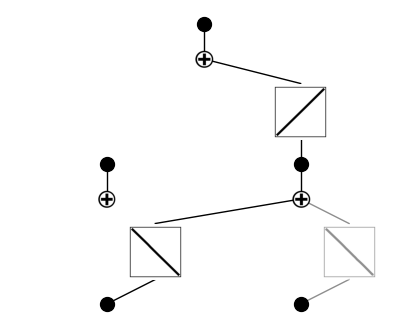

In [13]:
model_kan = model_kan.prune()
model_kan.plot()

lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)

formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN:", formula)
print(f"Реальная символьная формула: {-k/m} + {-c/m}")

# **Часть 3. Создание и обучение MLP [2,16,1] (65 параметров)**

In [10]:
class MLP(nn.Module):
    def __init__(self): # конструктор
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16), # слой
            nn.ReLU(), # функция активации
            nn.Linear(16, 1))
    def forward(self, x): # описывает как данные проходят через сеть
        return self.net(x)

model_mlp = MLP()
criterion = nn.MSELoss() # функция потерь
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001) # оптимизатор

# обучение
epochs = 8000
train_losses_mlp = []
test_losses_mlp = []

for epoch in range(epochs):
    model_mlp.train() # перевод в режим обучения
    optimizer.zero_grad() # обнуление градиентов
    # прямой проход
    pred = model_mlp(dataset['train_input'])
    loss = criterion(pred, dataset['train_label'])
    # обратный проход
    loss.backward()
    optimizer.step()

    if (epoch+1) % 800 == 0:
        model_mlp.eval()
        with torch.no_grad():
            test_loss = criterion(model_mlp(dataset['test_input']), dataset['test_label'])
        print(f"| train loss: {loss.item():.10f} | test loss: {test_loss.item():.10f} | MLP epoch {epoch+1}/{epochs}")

        train_losses_mlp.append(loss.item())
        test_losses_mlp.append(test_loss.item())

# финальная ошибка
model_mlp.eval()
with torch.no_grad():
    pred_mlp_scaled = model_mlp(dataset['test_input'])
    mse_mlp_scaled = criterion(pred_mlp_scaled, dataset['test_label'])
print(f"MSE MLP: {mse_mlp_scaled.item():.12f}")

| train loss: 0.0135412384 | test loss: 0.0122844419 | MLP epoch 800/8000
| train loss: 0.0024117806 | test loss: 0.0021752380 | MLP epoch 1600/8000
| train loss: 0.0008396178 | test loss: 0.0007517468 | MLP epoch 2400/8000
| train loss: 0.0005567940 | test loss: 0.0005134550 | MLP epoch 3200/8000
| train loss: 0.0004314121 | test loss: 0.0003985008 | MLP epoch 4000/8000
| train loss: 0.0003314794 | test loss: 0.0003053726 | MLP epoch 4800/8000
| train loss: 0.0002748016 | test loss: 0.0002634515 | MLP epoch 5600/8000
| train loss: 0.0002590877 | test loss: 0.0002554649 | MLP epoch 6400/8000
| train loss: 0.0002522803 | test loss: 0.0002540093 | MLP epoch 7200/8000
| train loss: 0.0002468040 | test loss: 0.0002551913 | MLP epoch 8000/8000
MSE MLP: 0.000255191262


# **График MSE от шагов/эпох**

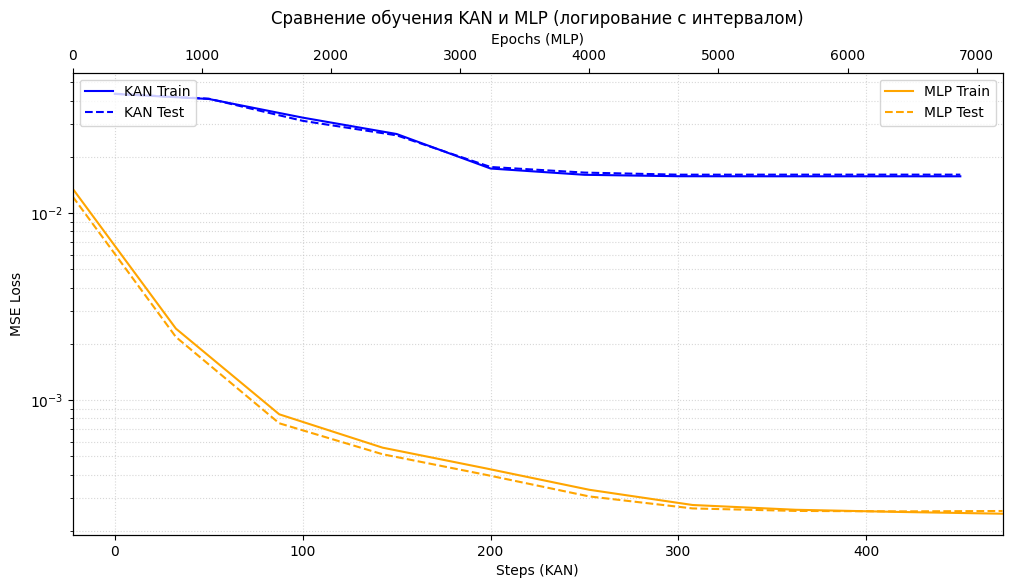

Символьная формула KAN: -4.0737*x_1 - 0.3019*x_2 - 0.0004
Реальная символьная формула: -4.0 + -0.3


In [14]:
import matplotlib.pyplot as plt

kan_steps = [i*50 for i in range(len(train_losses_kan))]
mlp_epochs = [i*800 for i in range(len(train_losses_mlp))]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Ось X для KAN (нижняя)
ax1.plot(kan_steps, train_losses_kan, label='KAN Train', color='blue', linestyle='-')
ax1.plot(kan_steps, test_losses_kan,  label='KAN Test',  color='blue', linestyle='--')
ax1.set_xlabel('Steps (KAN)')
ax1.set_ylabel('MSE Loss')
ax1.set_yscale('log')
ax1.legend(loc='upper left')
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# Ось X для MLP (верхняя)
ax2 = ax1.twiny()
ax2.plot(mlp_epochs, train_losses_mlp, label='MLP Train', color='orange', linestyle='-')
ax2.plot(mlp_epochs, test_losses_mlp,  label='MLP Test',  color='orange', linestyle='--')
ax2.set_xlabel('Epochs (MLP)')
ax2.legend(loc='upper right')
ax2.set_xlim(mlp_epochs[0], mlp_epochs[-1])   # чтобы шкала использовала всё пространство

plt.title('Сравнение обучения KAN и MLP (логирование с интервалом)')
plt.show()

print("Символьная формула KAN:", formula)
print(f"Реальная символьная формула: {-k/m} + {-c/m}")